Section 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


import time
from joblib import Parallel, delayed
import Levenshtein
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# SMOTE
from imblearn.over_sampling import SMOTE

# Deep Learning
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Explainable AI
import shap

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Deep Learning Imports
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import shap

SECTION 2: Load Dataset

In [3]:
# DATA LOADING
DATA_PATH = "cleaned_interaction_data.csv"   # <-- Replace with your actual filename

print(f"Loading data from: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("\nDataset Overview:")
print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns      : {list(df.columns)}")
print(f"Memory Usage : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

df.head()

Loading data from: cleaned_interaction_data.csv

Dataset Overview:
Shape        : 2,910,552 rows × 5 columns
Columns      : ['drug1_id', 'drug2_id', 'description', 'severity', 'severity_label']
Memory Usage : 899.44 MB


,drug1_id,drug2_id,description,severity,severity_label
0,DB00001,DB06605,Apixaban may increase the anticoagulant activi...,moderate,1
1,DB00001,DB06695,Dabigatran etexilate may increase the anticoag...,moderate,1
2,DB00001,DB01254,The risk or severity of bleeding and hemorrhag...,high,2
3,DB00001,DB01609,The risk or severity of gastrointestinal bleed...,moderate,1
4,DB00001,DB01586,The risk or severity of bleeding and bruising ...,moderate,1


SECTION 3: Basic EDA

In [4]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nOriginal Severity Distribution:")
print(df['severity'].value_counts())
print("\nSeverity Label Distribution:")
print(df['severity_label'].value_counts())

Data Types:
drug1_id          object
drug2_id          object
description       object
severity          object
severity_label     int64
dtype: object

Missing Values:
drug1_id          0
drug2_id          0
description       0
severity          0
severity_label    0
dtype: int64

Original Severity Distribution:
severity
moderate    2816046
high          91318
low            3188
Name: count, dtype: int64

Severity Label Distribution:
severity_label
1    2816046
2      91318
0       3188
Name: count, dtype: int64


SECTION 4: Class Engineering

In [5]:
# CLASS ENGINEERING
METABOLISM_KEYWORDS = [
    'metabolism', 'enzyme', 'CYP', 'cytochrome',
    'excretion', 'clearance', 'serum concentration'
]

def assign_new_class(row):
    severity = row['severity'].strip().lower()
    if severity == 'low':
        return 'Low'
    elif severity == 'high':
        return 'High'
    elif severity == 'moderate':
        desc = str(row['description']).lower()
        for kw in METABOLISM_KEYWORDS:
            if kw.lower() in desc:
                return 'Moderate-Metabolism'
        return 'Moderate-Other'
    else:
        return 'Unknown'

print("Applying class engineering")
df['severity_new'] = df.apply(assign_new_class, axis=1)

print("\nNew Class Distribution:")
print(df['severity_new'].value_counts())
print(f"\nUnknown assignments: {(df['severity_new'] == 'Unknown').sum()}")


Applying class engineering

New Class Distribution:
severity_new
Moderate-Other         1752878
Moderate-Metabolism    1063168
High                     91318
Low                       3188
Name: count, dtype: int64

Unknown assignments: 0


SECTION 5: ADVANCED EDA

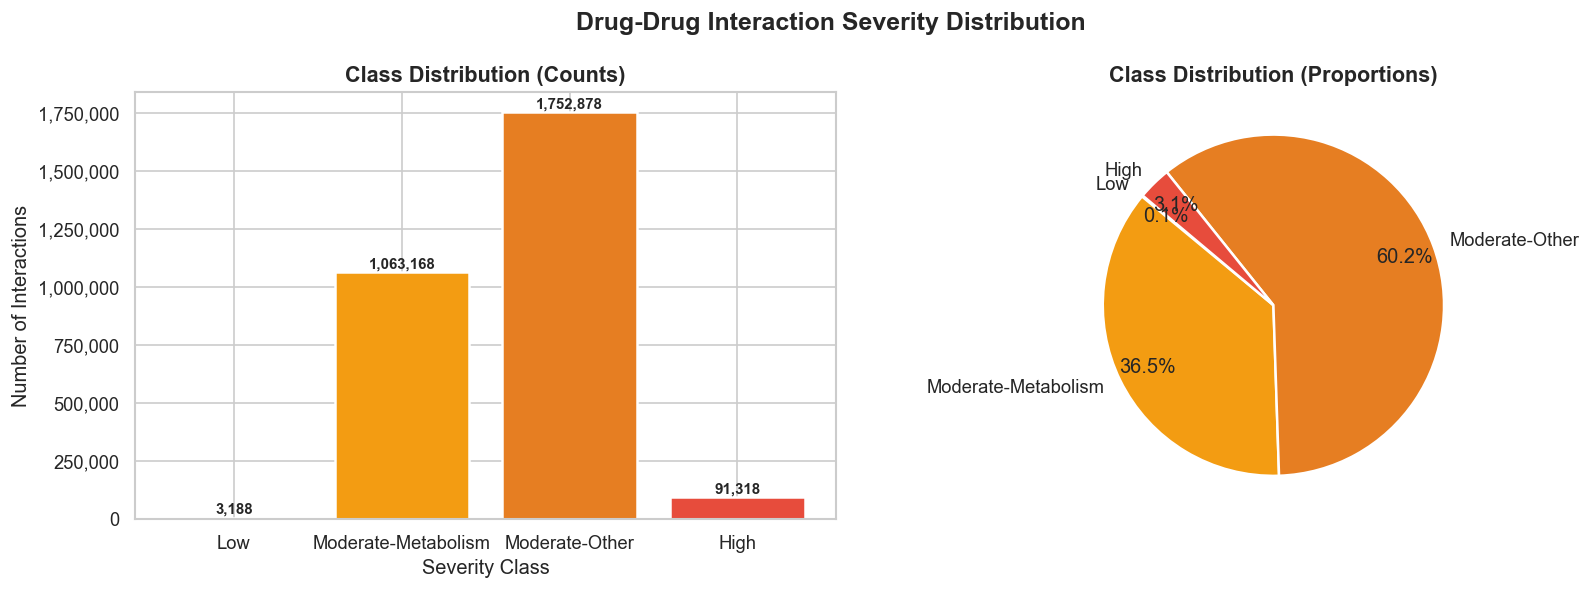

In [6]:
# EDA OF CLASS DISTRIBUTION
class_order = ['Low', 'Moderate-Metabolism', 'Moderate-Other', 'High']
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
counts = [df['severity_new'].value_counts().get(c, 0) for c in class_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(class_order, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Number of Interactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].pie(counts, labels=class_order, colors=colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Distribution (Proportions)', fontsize=13, fontweight='bold')

plt.suptitle('Drug-Drug Interaction Severity Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


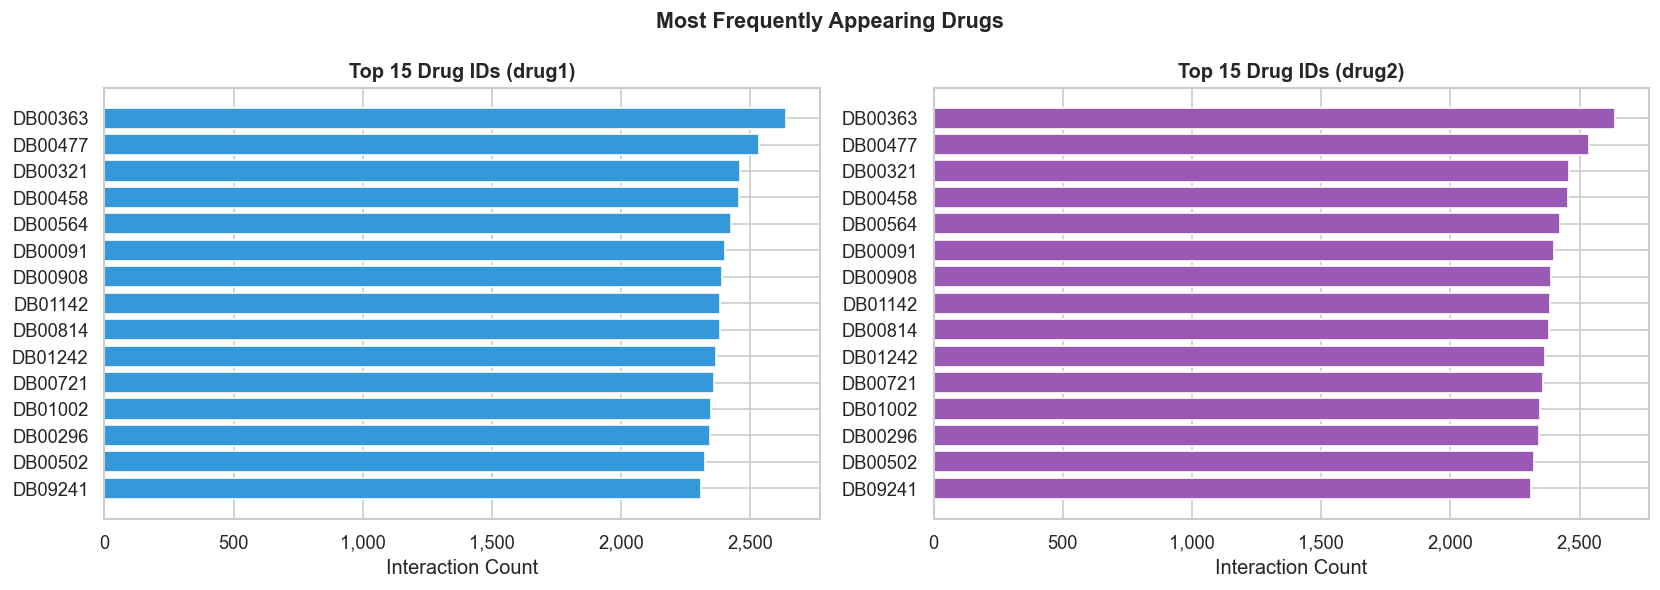

In [7]:
# EDA OF TOP DRUG IDS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_drug1 = df['drug1_id'].value_counts().head(15)
top_drug2 = df['drug2_id'].value_counts().head(15)

axes[0].barh(top_drug1.index[::-1], top_drug1.values[::-1], color='#3498db', edgecolor='white')
axes[0].set_title('Top 15 Drug IDs (drug1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Interaction Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(top_drug2.index[::-1], top_drug2.values[::-1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Top 15 Drug IDs (drug2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Interaction Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Most Frequently Appearing Drugs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_top_drugs.png', bbox_inches='tight', dpi=150)
plt.show()

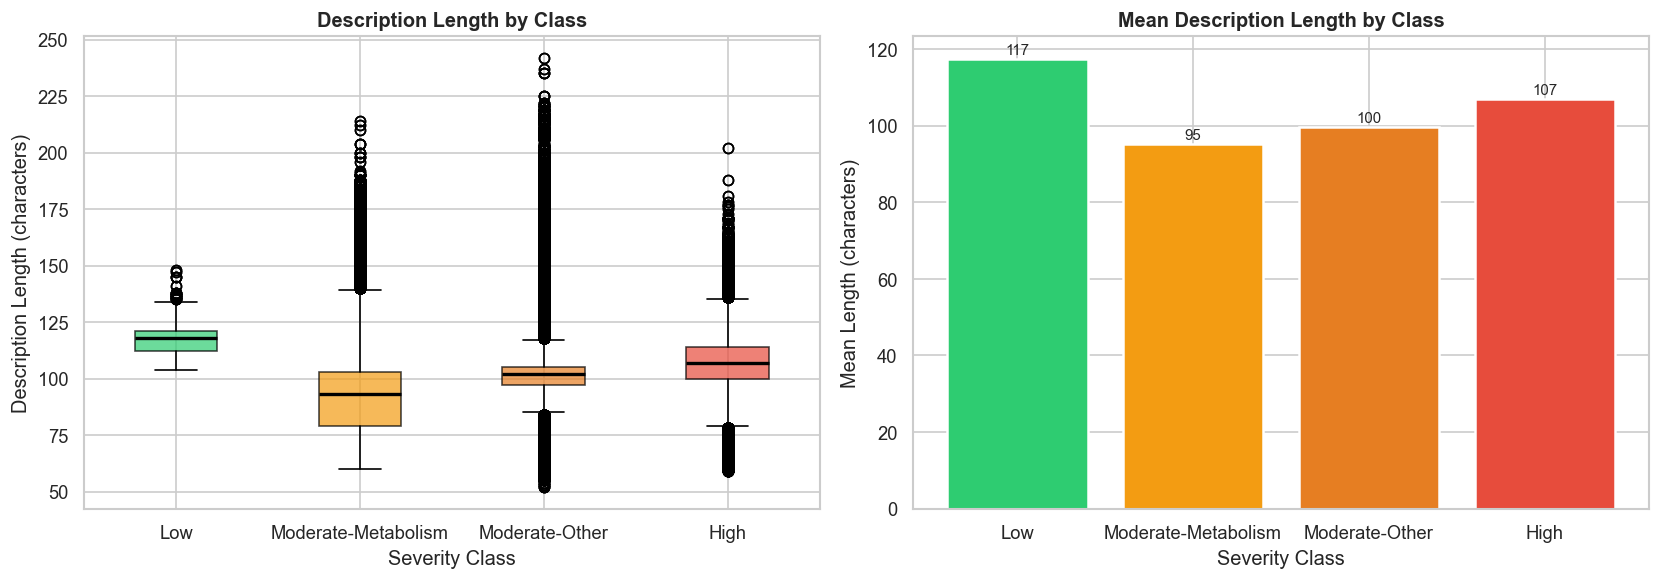

In [8]:
# EDA OF DESCRIPTION LENGTH
df['desc_length'] = df['description'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp_data = [df[df['severity_new'] == c]['desc_length'].values for c in class_order]
bp = axes[0].boxplot(bp_data, labels=class_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Description Length by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Description Length (characters)')

mean_lens = [df[df['severity_new'] == c]['desc_length'].mean() for c in class_order]
bars = axes[1].bar(class_order, mean_lens, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Mean Description Length by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Severity Class')
axes[1].set_ylabel('Mean Length (characters)')
for bar, v in zip(bars, mean_lens):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_description_length.png', bbox_inches='tight', dpi=150)
plt.show()

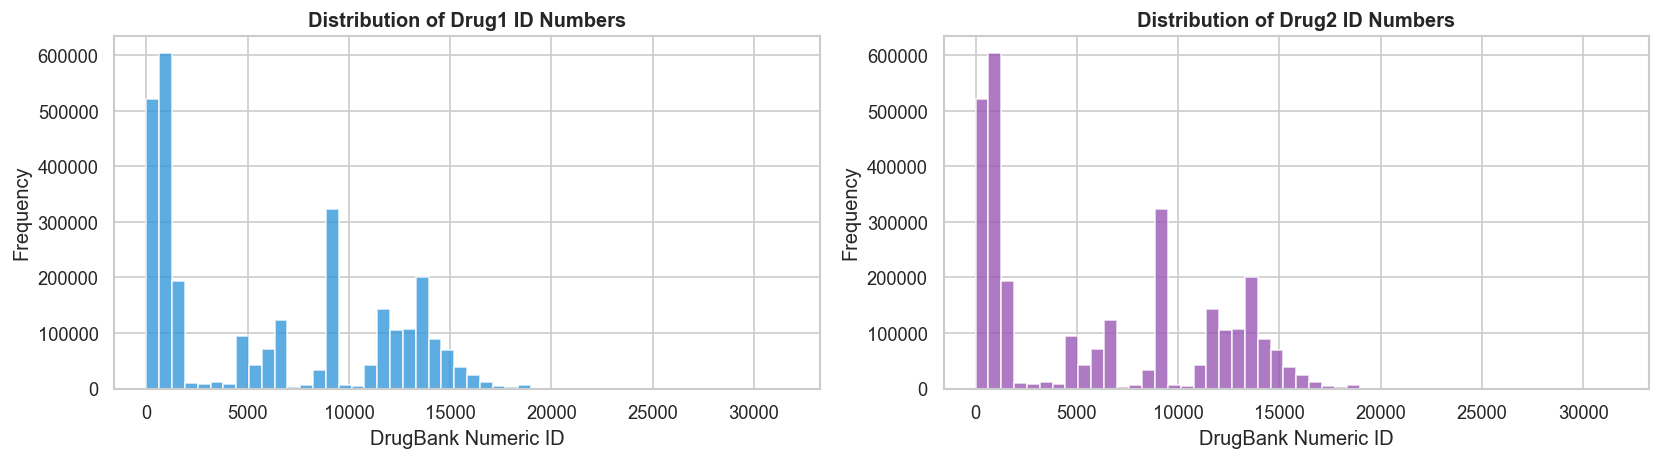

Drug1 ID range: DB00001 -> DB31654
Drug2 ID range: DB00001 -> DB31654
Total unique drugs: 4,629


In [9]:
# EDA OF DRUG ID NUMBER DISTRIBUTION
df['drug1_num'] = df['drug1_id'].str.extract(r'DB(\d+)').astype(float)
df['drug2_num'] = df['drug2_id'].str.extract(r'DB(\d+)').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['drug1_num'].dropna(), bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Drug1 ID Numbers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('DrugBank Numeric ID')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['drug2_num'].dropna(), bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Drug2 ID Numbers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('DrugBank Numeric ID')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_drug_id_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Drug1 ID range: DB{int(df['drug1_num'].min()):05d} -> DB{int(df['drug1_num'].max()):05d}")
print(f"Drug2 ID range: DB{int(df['drug2_num'].min()):05d} -> DB{int(df['drug2_num'].max()):05d}")
print(f"Total unique drugs: {pd.concat([df['drug1_id'], df['drug2_id']]).nunique():,}")


In [10]:
# LABEL ENCODING
all_drugs = pd.concat([df['drug1_id'], df['drug2_id']]).unique()
le_combined = LabelEncoder().fit(all_drugs)

df['drug1_encoded'] = le_combined.transform(df['drug1_id'])
df['drug2_encoded'] = le_combined.transform(df['drug2_id'])

print(f"Drug ID encoding complete.")
print(f"  Total unique drug IDs : {len(le_combined.classes_):,}")
print(f"  Encoding range        : 0 -> {len(le_combined.classes_) - 1}")
print(f"  Example: DB00001 -> {le_combined.transform(['DB00001'])[0]}")

Drug ID encoding complete.
  Total unique drug IDs : 4,629
  Encoding range        : 0 -> 4628
  Example: DB00001 -> 0


In [11]:
# LEVENSHTEIN SIMILARITY
def levenshtein_similarity(s1, s2):
    dist = Levenshtein.distance(str(s1), str(s2))
    max_len = max(len(str(s1)), len(str(s2)), 1)
    return 1.0 - (dist / max_len)

print("Computing Levenshtein similarity (parallelised)")
t0 = time.time()
lev_scores = Parallel(n_jobs=-1)(
    delayed(levenshtein_similarity)(d1, d2)
    for d1, d2 in zip(df['drug1_id'], df['drug2_id'])
)
df['lev_similarity'] = lev_scores
print(f"Done in {time.time() - t0:.1f} seconds")
print(df['lev_similarity'].describe().round(4))

Computing Levenshtein similarity (parallelised)
Done in 21.1 seconds
count    2.910552e+06
mean     4.483000e-01
std      1.243000e-01
min      2.857000e-01
25%      4.286000e-01
50%      4.286000e-01
75%      5.714000e-01
max      8.571000e-01
Name: lev_similarity, dtype: float64


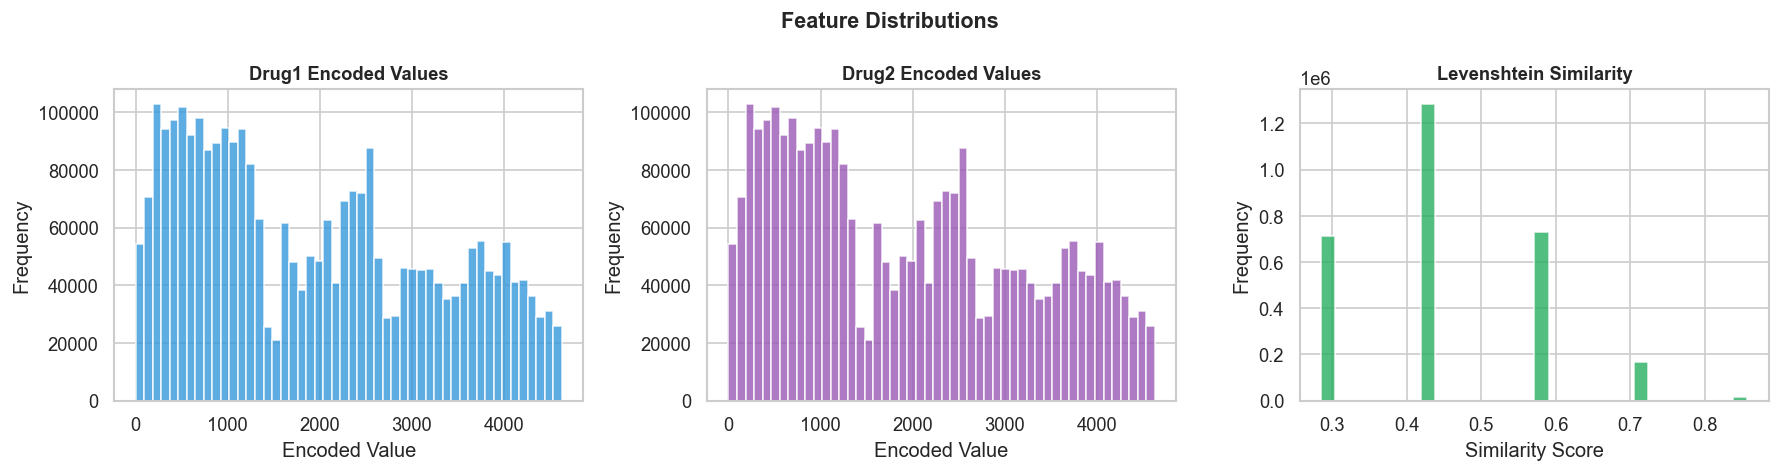

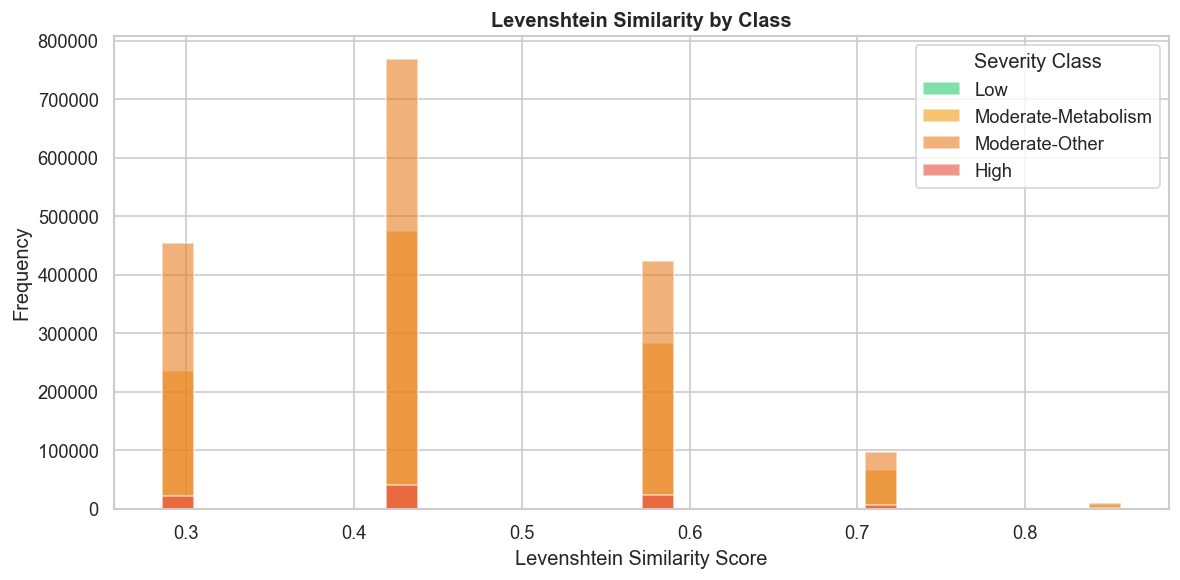

In [12]:
# FEATURE DISTRIBUTION PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['drug1_encoded'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Drug1 Encoded Values', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Encoded Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['drug2_encoded'], bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].set_title('Drug2 Encoded Values', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Encoded Value')
axes[1].set_ylabel('Frequency')

axes[2].hist(df['lev_similarity'], bins=30, color='#27ae60', edgecolor='white', alpha=0.8)
axes[2].set_title('Levenshtein Similarity', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Similarity Score')
axes[2].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for cls, color in zip(class_order, colors):
    subset = df[df['severity_new'] == cls]['lev_similarity']
    ax.hist(subset, bins=30, alpha=0.6, label=cls, color=color, edgecolor='white')
ax.set_title('Levenshtein Similarity by Class', fontsize=12, fontweight='bold')
ax.set_xlabel('Levenshtein Similarity Score')
ax.set_ylabel('Frequency')
ax.legend(title='Severity Class')
plt.tight_layout()
plt.savefig('lev_similarity_by_class.png', bbox_inches='tight', dpi=150)
plt.show()


SECTION 6: Feature Engineering and Train/Test Split

In [13]:
# ADDITIONAL FEATURE ENGINEERING


print("  ADDITIONAL FEATURE ENGINEERING")


df['drug_id_diff']    = (df['drug1_num'] - df['drug2_num']).abs()
df['drug_id_sum']     = df['drug1_num'] + df['drug2_num']
df['drug_id_ratio']   = df[['drug1_num', 'drug2_num']].min(axis=1) / \
                         df[['drug1_num', 'drug2_num']].max(axis=1).replace(0, 1)

df['desc_word_count'] = df['description'].astype(str).apply(lambda x: len(x.split()))
df['desc_has_cyp']    = df['description'].str.contains('CYP|cytochrome', case=False).astype(int)
df['desc_has_excret'] = df['description'].str.contains('excretion|clearance', case=False).astype(int)
df['desc_has_serum']  = df['description'].str.contains('serum|concentration', case=False).astype(int)

print("  New features added: drug_id_diff, drug_id_sum, drug_id_ratio,")
print("  desc_word_count, desc_has_cyp, desc_has_excret, desc_has_serum")

FEATURES = ['drug1_encoded', 'drug2_encoded', 'lev_similarity']

FEATURES_EXT = [
    'drug1_encoded', 'drug2_encoded', 'lev_similarity',
    'drug_id_diff', 'drug_id_sum', 'drug_id_ratio',
    'desc_word_count', 'desc_has_cyp', 'desc_has_excret', 'desc_has_serum'
]

TARGET = 'severity_new'

X_ext = df[FEATURES_EXT].copy()
y_ext = df[TARGET].copy()

le_target = LabelEncoder()
y_ext_encoded = le_target.fit_transform(y_ext)

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y_ext_encoded,
    test_size=0.2, random_state=42, stratify=y_ext_encoded
)

#feature scaling
scaler = StandardScaler()

X_train_ext = scaler.fit_transform(X_train_ext)
X_test_ext = scaler.transform(X_test_ext)

print("Feature scaling completed.")
print(f"\n  Extended feature matrix : {X_ext.shape}")
print(f"  Train : {X_train_ext.shape[0]:,}  |  Test : {X_test_ext.shape[0]:,}")
print(f"\n  Class label mapping:")
for i, cls in enumerate(le_target.classes_):
    print(f"    {i} -> {cls}")


  ADDITIONAL FEATURE ENGINEERING
  New features added: drug_id_diff, drug_id_sum, drug_id_ratio,
  desc_word_count, desc_has_cyp, desc_has_excret, desc_has_serum
Feature scaling completed.

  Extended feature matrix : (2910552, 10)
  Train : 2,328,441  |  Test : 582,111

  Class label mapping:
    0 -> High
    1 -> Low
    2 -> Moderate-Metabolism
    3 -> Moderate-Other


SECTION 7: SMOTE

 OPTIMISED SMOTE
  After optimised SMOTE — shape : (4767825, 10)
  Class distribution:
Moderate-Other         1402302
Moderate-Metabolism    1121841
High                   1121841
Low                    1121841
Name: count, dtype: int64


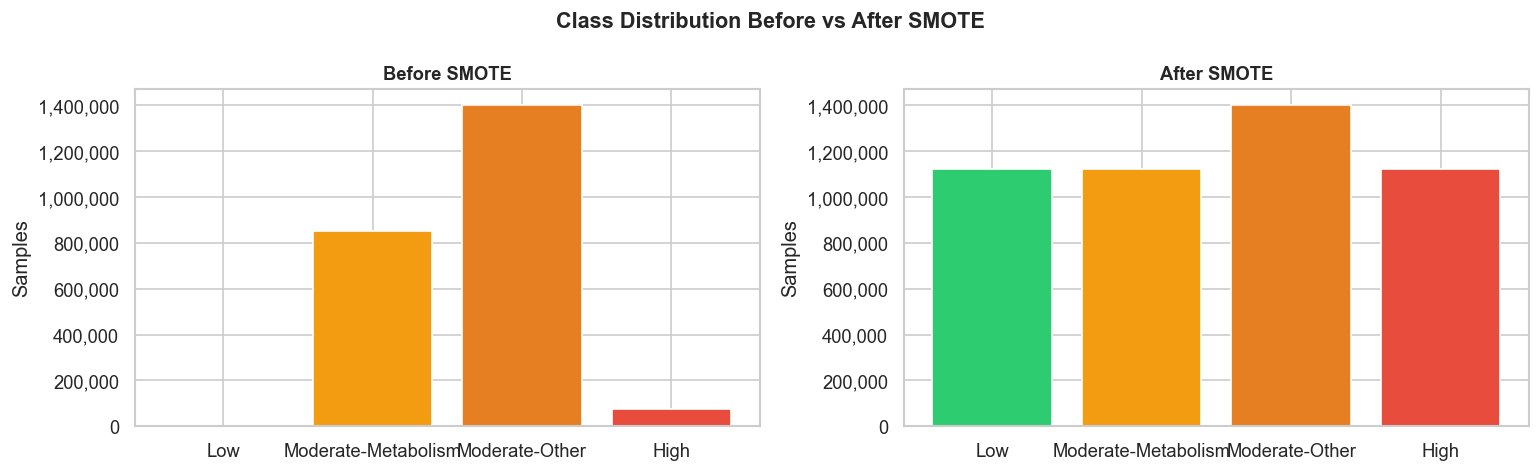

In [14]:

# OPTIMISED SMOTE

print(" OPTIMISED SMOTE")

majority_count = pd.Series(y_train_ext).value_counts().max()
cap = int(majority_count * 0.8)
class_counts = pd.Series(y_train_ext).value_counts().to_dict()

sampling_strategy = {}
for cls, count in class_counts.items():
    if count < cap:

        sampling_strategy[cls] = cap
    else:

        sampling_strategy[cls] = count

smote_opt = SMOTE(
    k_neighbors=5,
    sampling_strategy=sampling_strategy,
    random_state=42
)
X_train_sm_ext, y_train_sm_ext = smote_opt.fit_resample(X_train_ext, y_train_ext)

after_dist_ext = (pd.Series(y_train_sm_ext)
                    .map(dict(enumerate(le_target.classes_)))
                    .value_counts())
print(f"  After optimised SMOTE — shape : {X_train_sm_ext.shape}")
print(f"  Class distribution:\n{after_dist_ext}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
before_counts = pd.Series(y_train_ext).map(dict(enumerate(le_target.classes_))).value_counts()
before_counts = before_counts.reindex(class_order).fillna(0)
after_counts  = after_dist_ext.reindex(class_order).fillna(0)

axes[0].bar(before_counts.index, before_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Samples')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(after_counts.index, after_counts.values, color=colors, edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Samples')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

SECTION 8: Validation Split

In [15]:
# MODEL TRAINING


print(" MODEL TRAINING ")


X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm_ext, y_train_sm_ext,
    test_size=0.1, random_state=42,
    stratify=y_train_sm_ext
)


 MODEL TRAINING 


SECTION 9: Deep Neural Network

In [16]:
print("TRAINING DEEP NEURAL NETWORK")

num_features = X_tr.shape[1]
num_classes = len(np.unique(y_tr))

dnn_model = Sequential([

    Dense(128,
          activation='relu',
          input_shape=(num_features,)),

    BatchNormalization(),

    Dropout(0.30),

    Dense(64,
          activation='relu'),

    BatchNormalization(),

    Dropout(0.30),

    Dense(32,
          activation='relu'),

    Dense(num_classes,
          activation='softmax')

])

dnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

dnn_model.summary()

TRAINING DEEP NEURAL NETWORK


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,644 (49.39 KB)

 Trainable params: 12,260 (47.89 KB)

 Non-trainable params: 384 (1.50 KB)

SECTION 10: Train DNN

In [17]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

history = dnn_model.fit(

    X_tr,

    y_tr,

    validation_data=(X_val, y_val),

    epochs=50,

    batch_size=256,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/50
16762/16762 ━━━━━━━━━━━━━━━━━━━━ 118s 7ms/step - accuracy: 0.7773 - loss: 0.4903 - val_accuracy: 0.7996 - val_loss: 0.4347
Epoch 2/50
16762/16762 ━━━━━━━━━━━━━━━━━━━━ 115s 7ms/step - accuracy: 0.7945 - loss: 0.4527 - val_accuracy: 0.8053 - val_loss: 0.4261
Epoch 3/50
16762/16762 ━━━━━━━━━━━━━━━━━━━━ 117s 7ms/step - accuracy: 0.7975 - loss: 0.4464 - val_accuracy: 0.8061 - val_loss: 0.4270
Epoch 4/50
16762/16762 ━━━━━━━━━━━━━━━━━━━━ 116s 7ms/step - accuracy: 0.7991 - loss: 0.4427 - val_accuracy: 0.8058 - val_loss: 0.4222
Epoch 5/50
16762/16762 ━━━━━━━━━━━━━━━━━━━━ 115s 7ms/step - accuracy: 0.8010 - loss: 0.4395 - val_accuracy: 0.8090 - val_loss: 0.4178
Epoch 6/50
16762/16762 ━━━━━━━━━━━━━━━━━━━━ 121s 7ms/step - accuracy: 0.8018 - loss: 0.4380 - val_accuracy: 0.8083 - val_loss: 0.4185
Epoch 7/50
16762/16762 ━━━━━━━━━━━━━━━━━━━━ 120s 7ms/step - accuracy: 0.8024 - loss: 0.4365 - val_accuracy: 0.8100 - val_loss: 0.4169
Epoch 8/50
16762/16762 ━━━━━━━━━━━━━━━━━━━━ 121s 7ms/step - ac

SECTION 11: Training curves

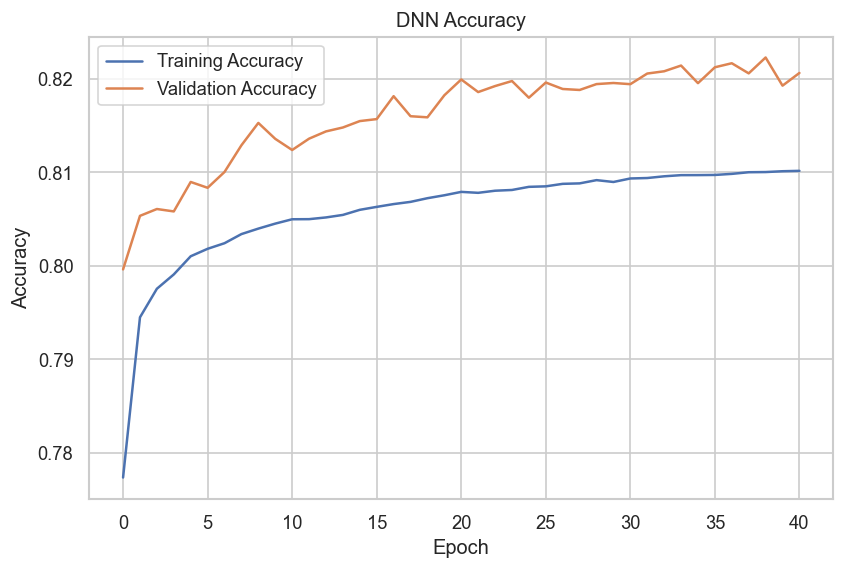

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("DNN Accuracy")

plt.legend()

plt.show()

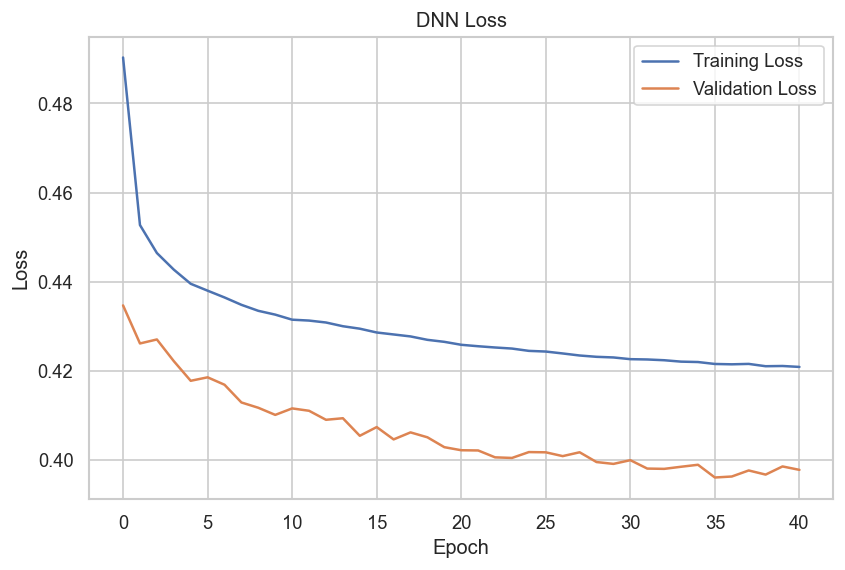

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("DNN Loss")

plt.legend()

plt.show()

SECTION 12: Evaluate Model

18191/18191 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step
                     precision    recall  f1-score   support

               High       0.16      0.55      0.24     18264
                Low       0.03      0.92      0.05       637
Moderate-Metabolism       0.99      1.00      0.99    212634
     Moderate-Other       0.98      0.79      0.87    350576

           accuracy                           0.86    582111
          macro avg       0.54      0.81      0.54    582111
       weighted avg       0.95      0.86      0.89    582111



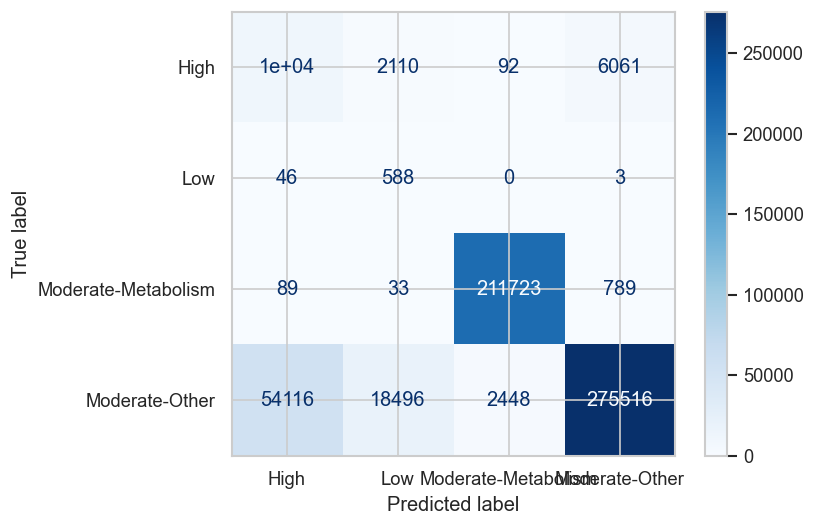

In [20]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

pred_prob = dnn_model.predict(X_test_ext)

pred_class = np.argmax(pred_prob, axis=1)

print(classification_report(

    y_test_ext,

    pred_class,

    target_names=le_target.classes_

))

cm = confusion_matrix(

    y_test_ext,

    pred_class

)

ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=le_target.classes_

).plot(cmap="Blues")

plt.show()

SECTION 13: Explainable AI (SHAP)

In [21]:
print("Generating SHAP explanations...")

background = X_train_sm_ext[:100]

explainer = shap.KernelExplainer(

    dnn_model.predict,

    background

)

sample = X_test_ext[:50]

shap_values = explainer.shap_values(sample)

Generating SHAP explanations...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
3194/3194 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

SECTION 14: SHAP Summary Plot

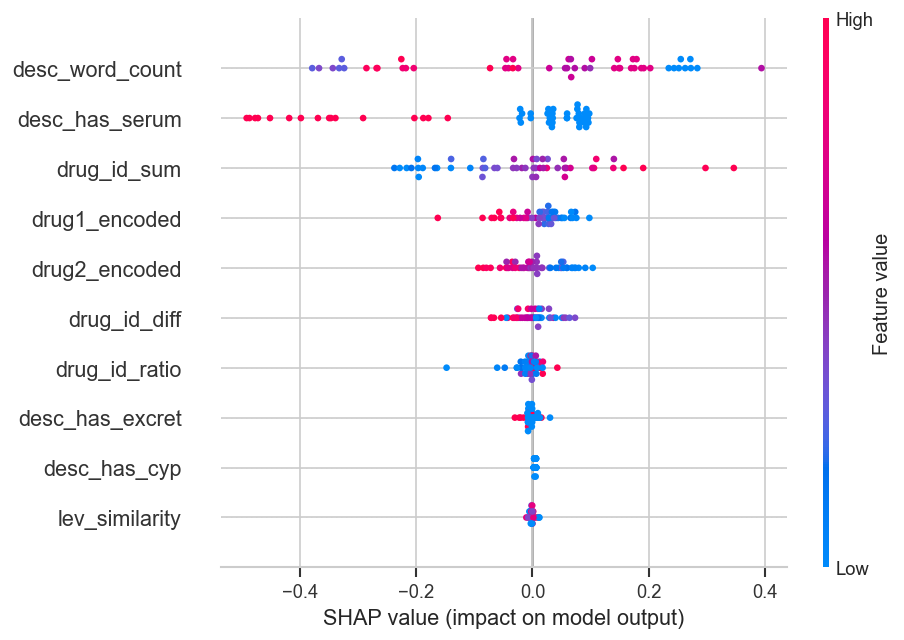

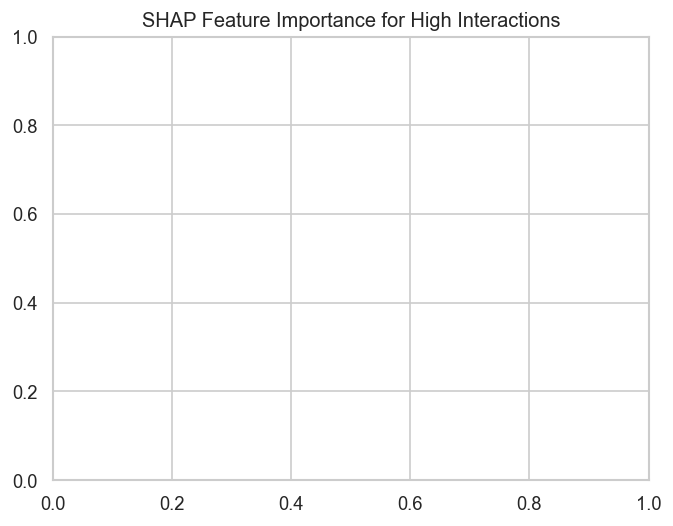

In [22]:
CLASS_NAMES = [
    "Low",
    "Moderate-Metabolism",
    "Moderate-Other",
    "High"
]

CLASS_INDEX = 3  # High severity

shap.summary_plot(
    shap_values[:, :, CLASS_INDEX],
    sample,
    feature_names=FEATURES_EXT,
    show=True
)

plt.title(f"SHAP Feature Importance for {CLASS_NAMES[CLASS_INDEX]} Interactions")
plt.show()


Low Class


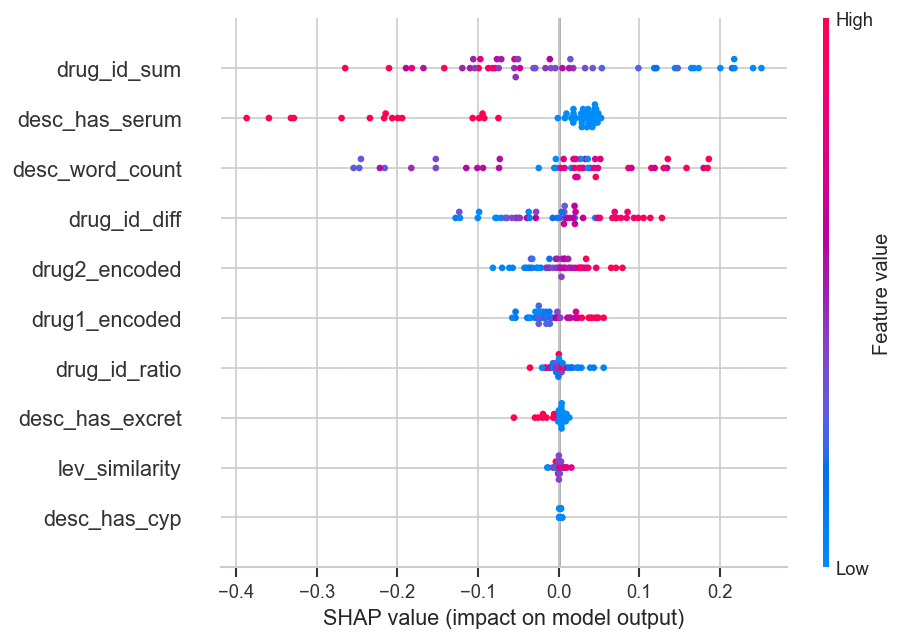


Moderate-Metabolism Class


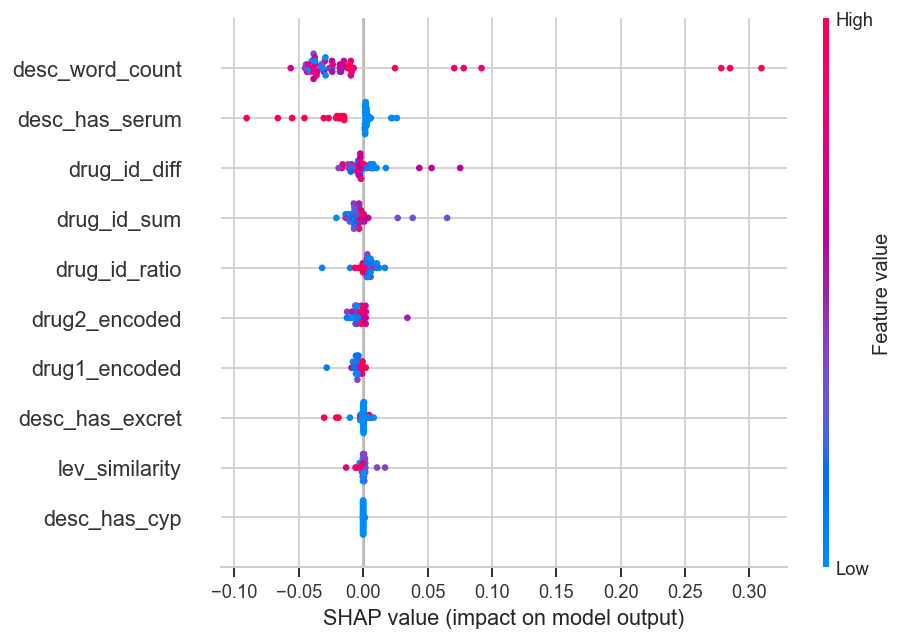


Moderate-Other Class


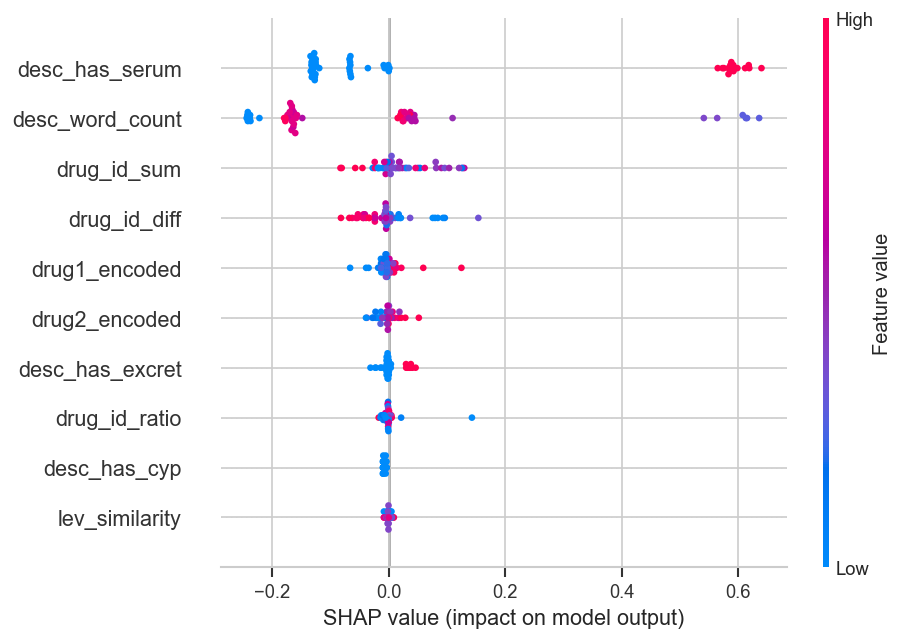


High Class


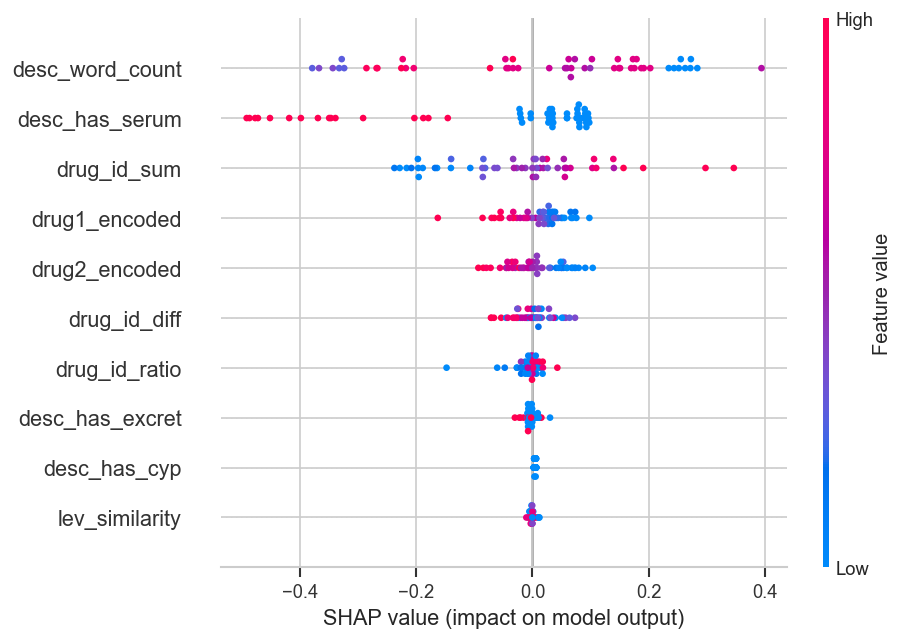

In [23]:
CLASS_NAMES = [
    "Low",
    "Moderate-Metabolism",
    "Moderate-Other",
    "High"
]

for i, class_name in enumerate(CLASS_NAMES):

    print(f"\n{class_name} Class")

    shap.summary_plot(
        shap_values[:, :, i],
        sample,
        feature_names=np.array(FEATURES_EXT),
        show=True
    )

SECTION 15: SHAP Force Plot

In [25]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[0],
    shap_values[0, :, 0],
    sample[0],
    feature_names=FEATURES_EXT
)

SECTION 16: Save Model

In [26]:
dnn_model.save("drug_interaction_dnn.keras")

print("Model saved successfully.")

Model saved successfully.
